Governing equations:
$$
\begin{gathered}
\partial_t \hat{\nabla}^2 \hat{w}+\mathrm{i} k_x \bar{U}_0 \hat{\nabla}^2 \hat{w}-\mathrm{i} k_x \bar{U}_0^{\prime \prime} \hat{w}=\operatorname{Pr} \hat{\nabla}^4 \hat{w}+\operatorname{Pr} \hat{\nabla}_{\perp}^2 \operatorname{Ra}\left(\hat{T}-R_\rho^{-1} \hat{S}\right), \\
\partial_t \hat{\zeta}+\mathrm{i} k_x \bar{U}_0 \hat{\zeta}+\mathrm{i} k_y \bar{U}_0^{\prime} \hat{w}=\operatorname{Pr} \hat{\nabla}^2 \hat{\zeta}, \\
\partial_t \hat{T}+\mathrm{i} k_x \bar{U}_0 \hat{T}+\hat{w} \partial_z \bar{T}_0+\hat{w}=\hat{\nabla}^2 \hat{T}, \\
\partial_t \hat{S}+\mathrm{i} k_x \bar{U}_0 \hat{S}+\hat{w} \partial_z \bar{S}_0+\hat{w}=\tau \hat{\nabla}^2 \hat{S}, \\
\partial_t \bar{U}_0+\partial_z\left(\hat{w}^* \hat{u}+\hat{w} \hat{u}^*\right)=\operatorname{Pr} \partial_z^2 \bar{U}_0, \\
\partial_t \bar{T}_0+\partial_z\left(\hat{w}^* \hat{T}+\hat{w} \hat{T}^*\right)=\partial_z^2 \bar{T}_0, \\
\partial_t \bar{S}_0+\partial_z\left(\hat{w}^* \hat{S}+\hat{w} \hat{S}^*\right)=\tau \partial_z^2 \bar{S}_0, \\
\hat{u}=\frac{\mathrm{i} k_x \partial_z \hat{w}}{k_x^2+k_y^2}-\frac{\mathrm{i} k_y \hat{\zeta}}{k_x^2+k_y^2}, \quad \hat{v}=\frac{\mathrm{i} k_y \partial_z \hat{w}}{k_x^2+k_y^2}+\frac{\mathrm{i} k_x \hat{\zeta}}{k_x^2+k_y^2},
\end{gathered}
$$
where the superscript * denotes a complex conjugate and $\hat{\nabla}^2:=\partial_z^2-k_x^2-k_y^2, \hat{\nabla}_{\perp}^2:=$ $-k_x^2-k_y^2, \quad \hat{\nabla}^4:=\partial_z^4-2\left(k_x^2+k_y^2\right) \partial_z^2+\left(k_x^2+k_y^2\right)^2, \quad \bar{U}_0^{\prime}:=\partial_z \bar{U}_0$ and $\bar{U}_0^{\prime \prime}:=\partial_z^2 \bar{U}_0$. 

/home/ducubuntu/miniforge-pypy3/envs/dedalus3/lib/python3.12/site-packages/numpy/core/getlimits.py:542: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


2024-07-07 17:38:00,686 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 9.9e+00/s
Starting main loop
Completed iteration 1000
Completed iteration 2000
Completed iteration 3000
Completed iteration 4000
Completed iteration 5000
Completed iteration 6000
2024-07-07 17:38:43,547 solvers 0/1 INFO :: Simulation stop time reached.


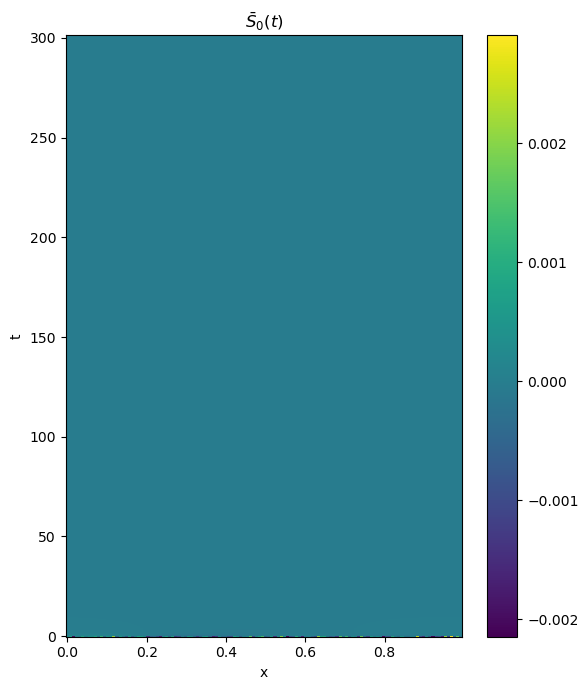

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3

# Parameters
kx, ky = 8, 0   # wavenumber
Lz = 1          # computational domain
Nz = 128        # number of points
dealias = 3/2   # scaling factor

Ra = 1e5        # Rayleigh number
Pr = 7          # Prandtl number
tau = 0.01      # diffusivity ratio = ks/kt
Rp = 40.0       # density ratio

# Bases
coords = d3.Coordinate('z')
dist = d3.Distributor(coords, dtype=np.complex128)
# define the coordinate system
zbasis = d3.ComplexFourier(coords, size=Nz, bounds=(0, Lz), dealias=dealias)

# define fields for single-mode equations
barU0   = dist.Field(name='barU0', bases=(zbasis)) 
hatu    = dist.Field(name='hatu', bases=(zbasis)) 
hatw    = dist.Field(name='hatw', bases=(zbasis)) 
hatzeta = dist.Field(name='hatzeta', bases=(zbasis)) 
barT0   = dist.Field(name='barT0', bases=(zbasis)) 
hatT    = dist.Field(name='hatT', bases=(zbasis)) 
barS0   = dist.Field(name='barS0', bases=(zbasis)) 
hatS    = dist.Field(name='hatS', bases=(zbasis)) 

# Substitutions
z = dist.local_grids(zbasis) # get coordinate arrays in horizontal and vertical directions

i = 1j
conj = lambda A: np.conj(A)
dz = lambda A: d3.Differentiate(A, coords) 

kx2ky2 = kx*kx+ky*ky
hatnabla2 = lambda A: (dz(dz(A))-kx2ky2*A)
hatnabla2perp = (-kx2ky2)
hatnabla4 = lambda A: (dz(dz(dz(dz(A)))) - 2*kx2ky2*dz(dz(A)) + kx2ky2*kx2ky2*A)

# Problem
problem = d3.IVP([barU0,
                  hatu,
                  hatw,
                  hatzeta,
                  barS0,
                  hatS,
                  barT0,
                  hatT,
                  ], namespace=locals())
problem.add_equation("dt(hatnabla2(hatw)) - Pr*hatnabla4(hatw) - Pr*hatnabla2perp*Ra*(hatT-(1./Rp)*hatS) = - i*kx*barU0*hatnabla2(hatw) + i*kx*dz(dz(barU0))*hatw")
problem.add_equation("dt(hatzeta) - Pr*hatnabla2(hatzeta) = - i*kx*barU0*hatzeta")
problem.add_equation("dt(hatT) - hatnabla2(hatT) + hatw = - i*kx*barU0*hatT - hatw*dz(barT0)")
problem.add_equation("dt(hatS) - tau*hatnabla2(hatS) = - i*kx*barU0*hatS - hatw*dz(barS0)")
problem.add_equation("dt(barU0) - Pr*dz(dz(barU0)) = - dz(conj(hatw)*hatu+hatw*conj(hatu))")
problem.add_equation("dt(barT0) - dz(dz(barT0)) = - dz(conj(hatw)*hatT+hatw*conj(hatT))")
problem.add_equation("dt(barS0) - tau*dz(dz(barS0)) = - dz(conj(hatw)*hatS+hatw*conj(hatS))")
problem.add_equation("hatu = i*kx*dz(hatw)/kx2ky2 - i*ky*hatzeta/kx2ky2")

stop_sim_time = 301 # Stopping criteria
# timestepper = d3.RK443 # 3rd-order 4-stage DIRK+ERK scheme [Ascher 1997 sec 2.8] doi 10.1016/S0168-9274(97)00056-1
timestepper = d3.RK222
# Solver
solver = problem.build_solver(timestepper)
solver.stop_sim_time = stop_sim_time

barU0.fill_random('g', seed=42, distribution='normal', scale=1e-3) # Random noise
hatu.fill_random('g', seed=42, distribution='normal', scale=1e-3) # Random noise
hatw.fill_random('g', seed=42, distribution='normal', scale=1e-3) # Random noise
hatzeta.fill_random('g', seed=42, distribution='normal', scale=1e-3) # Random noise
barS0.fill_random('g', seed=42, distribution='normal', scale=1e-3) # Random noise
hatS.fill_random('g', seed=42, distribution='normal', scale=1e-3) # Random noise
barT0.fill_random('g', seed=42, distribution='normal', scale=1e-3) # Random noise
hatT.fill_random('g', seed=42, distribution='normal', scale=1e-3) # Random noise

# Analysis
import glob
import os
sim_name = "singlemode"
if os.path.exists(sim_name):
    dir_path = '/'+sim_name
    file_pattern = sim_name+"s*.h5" # pattern for file names to be deleted
    file_paths = glob.glob(os.path.join(dir_path, file_pattern)) # get a list of file paths using the glob module
    # loop over each file path and delete the file
    for file_path in file_paths:
        os.remove(file_path)

dataset = solver.evaluator.add_file_handler(sim_name, sim_dt=50.0, max_writes=1000)
dataset.add_task(barU0, name='barU0')
dataset.add_task(hatu, name='hatu')
dataset.add_task(hatw, name='hatw')
dataset.add_task(barS0, name='barS0')
dataset.add_task(hatS, name='hatS')

# Setup storage
barS0.change_scales(1)
barS0_list = [np.copy(barS0['g'])]
t_list = [solver.sim_time]
# Main loop
print('Starting main loop')
timestep = 0.05
while solver.proceed:
    solver.step(timestep)
    if solver.iteration % 10 == 0:
        barS0.change_scales(1)
        barS0_list.append(np.copy(barS0['g']))
        t_list.append(solver.sim_time)
    if solver.iteration % 1000 == 0:
        print('Completed iteration {}'.format(solver.iteration))
        # print(barS0['g'])

# Convert storage lists to arrays
barS0_array = np.array(barS0_list)
t_array = np.array(t_list)

# Plot solution
plt.figure(figsize=(6, 7), dpi=100)
plt.pcolormesh(z, t_array, np.real(barS0_array), shading='nearest')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('t')
plt.title(r'$\bar{S}_0(t)$')
plt.tight_layout()
plt.savefig("BarS0.png", dpi=300, bbox_inches="tight")
plt.show()